# **Air Quality Monitor Representativeness in the Contiguous United States**

#### **Objective:** Determine whether state and local governments site air monitors in areas that capture data that are representative of actual air quality. For this analysis, compare the cleaned EPA PM2.5 monitor dataset with the extracted alternative PM2.5 estimates on a daily basis to assess the quality of the alternative dataset for the purpose of answering my research question.

#### **Scope:** EPA monitor locations and their daily PM2.5 measurements in the contiguous United States in 2019 and daily PM2.5 estimates derived from an alternative air quality dataset during the same time period and frequency.

#### **Sources:**

| Num. | Title | Description | Source Link |
| :--- | :------------------------------ | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. | _daily_88101_2019_processed_v02.csv_ | This processed dataset contains each PM2.5 monitor location and their alternative PM2.5 estimates for every day in the year 2019 within the contiguous United States. | NA <br><br> (Developed by this project in B_air_monitors_w_alt_data_extraction)

#### **Conclusions:** The non-transformed and natural log transformed alternative PM2.5 dataset has a strong positive relationship with the non-transformed and natural log transformed actual PM2.5 dataset, respectively, and each correlation is statistically significant. While the data's non-normal distribution may undermine the validity of my conclusions, I assume from this analysis that the alternative PM2.5 data sufficiently represents actual PM2.5 to determine whether state and local governments site air monitors in areas that capture data that are representative of actual air quality.



#### General Methodology

##### Steps

1. Load Libraries
2. Explore Monitors with Alternative PM2.5 Data
3. Compare alt data to actual data pre-transformed
4. Compare alt data to actual data post-transformed

#### Load Libraries



In [3]:
#Purpose of Cell Block: Load libraries I will likely need
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(readr))
suppressPackageStartupMessages(library(vroom))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(terra))
suppressPackageStartupMessages(library(naniar))
suppressPackageStartupMessages(library(GGally))
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(ggtext))


if (!require(dplyr)) install.packages("dplyr")
if (!require(dplyr)) install.packages("tidyr")
if (!require(readr)) install.packages("readr")
if (!require(vroom)) install.packages("vroom")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(stringr)) install.packages("stringr")
if (!require(terra)) install.packages("terra")
if (!require(naniar)) install.packages("naniar")
if (!require(GGally)) install.packages("GGally")
if (!require(tidyverse)) install.packages("tidyverse")
if (!require(ggtext)) install.packages("ggtext")

library(dplyr)
library(tidyr)
library(readr)
library(vroom)
library(ggplot2)
library(stringr)
library(terra)
library(naniar)
library(GGally)
library(tidyverse)
library(ggtext)

#### Monitors with Alternative PM2.5 Data \- Exploration of Dataset



In [4]:
#Purpose of Cell Block: Load Processed AQM+AltPM25 Dataset 
setwd("/home/user/capstone/A_data")
DF_altpm25_processed <- read.csv("D_processed_data/alternative_PM25_data/alternative_PM25_data_processed_v02.csv") %>%
    mutate('AQS_Site_ID' = str_pad(AQS_Site_ID, width = 9, pad = 0)) %>% #pad leading zero so state code always 9 char
    mutate(Date = as.Date(Date)) #converting date value from character to date

head(DF_altpm25_processed)

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3,Alt_PM25
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>
1,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-01,NA,7.2
2,010270001,33.28493,-85.80361,ASHLAND AIRPORT,Alabama,Clay,Ashland,2019-01-01,NA,6.0
3,010331002,34.76262,-87.63810,WILSON DAM RD AND 2ND ST.,Alabama,Colbert,Muscle Shoals,2019-01-01,NA,5.0
4,010491003,34.28857,-85.96986,"13112 HWY.68 , CROSSVILLE AL. 35962",Alabama,DeKalb,Crossville,2019-01-01,NA,6.2
5,010550010,33.98821,-85.99256,"314 COLLEGE DRIVE, GADSDEN, AL 35902",Alabama,Etowah,Gadsden,2019-01-01,NA,7.9
6,010690003,31.22478,-85.39079,126 NORTH ST. ANDREWS STREET (CIVIC CENTER),Alabama,Houston,Dothan,2019-01-01,NA,10.4


In [5]:
#Purpose of Cell: Check Missingness

glimpse(DF_altpm25_processed)
summary(DF_altpm25_processed)

#Visualize missingness
print("Variables with Missing Data (Percent):")
DF_altpm25_processed %>%
    summarise(across(everything(), ~mean(is.na(.)) * 100)) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "missing_percent")  %>%
    filter(missing_percent > 0)

#Conclusion: Missingness doesn't appear to be a significant problem in the dataset, though I need to check the type of missingness.

Rows: 350,896
Columns: 10
$ AQS_Site_ID <chr> "010030010", "010270001", "010331002", "010491003", "01055…
$ Latitude    <dbl> 30.49748, 33.28493, 34.76262, 34.28857, 33.98821, 31.22478…
$ Longitude   <dbl> -87.88026, -85.80361, -87.63810, -85.96986, -85.99256, -85…
$ Address     <chr> "FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE,  ALABAMA"…
$ State       <chr> "Alabama", "Alabama", "Alabama", "Alabama", "Alabama", "Al…
$ County      <chr> "Baldwin", "Clay", "Colbert", "DeKalb", "Etowah", "Houston…
$ City        <chr> "Fairhope", "Ashland", "Muscle Shoals", "Crossville", "Gad…
$ Date        <date> 2019-01-01, 2019-01-01, 2019-01-01, 2019-01-01, 2019-01-0…
$ PM25_ugm3   <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ Alt_PM25    <dbl> 7.2, 6.0, 5.0, 6.2, 7.9, 10.4, 7.3, 5.3, 6.7, 6.5, 7.9, 5.…


 AQS_Site_ID           Latitude       Longitude         Address         
 Length:350896      Min.   :25.47   Min.   :-124.18   Length:350896     
 Class :character   1st Qu.:35.26   1st Qu.:-106.62   Class :character  
 Mode  :character   Median :39.41   Median : -89.07   Mode  :character  
                    Mean   :38.66   Mean   : -93.75                     
                    3rd Qu.:41.71   3rd Qu.: -81.39                     
                    Max.   :48.76   Max.   : -68.02                     
                                                                        
    State              County              City                Date           
 Length:350896      Length:350896      Length:350896      Min.   :2019-01-01  
 Class :character   Class :character   Class :character   1st Qu.:2019-04-02  
 Mode  :character   Mode  :character   Mode  :character   Median :2019-07-02  
                                                          Mean   :2019-07-02  
                     

[1] "Variables with Missing Data (Percent):"


variable,missing_percent
<chr>,<dbl>
PM25_ugm3,42.7126556
Alt_PM25,0.3265925


#### Compare Data Pre-Transformation

Warning message:
“Removed 151023 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


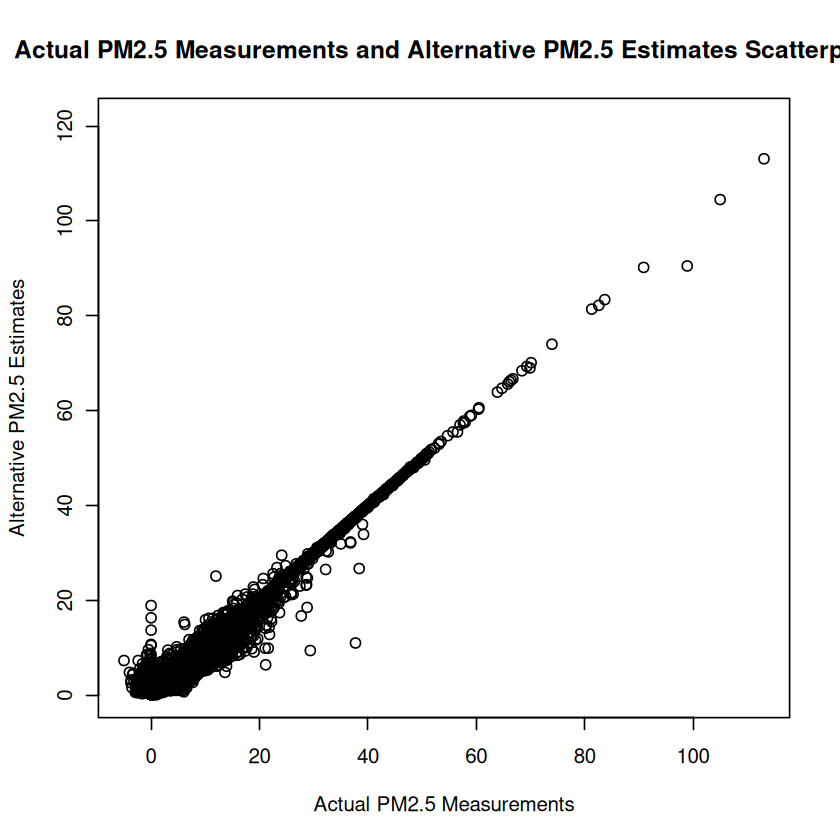

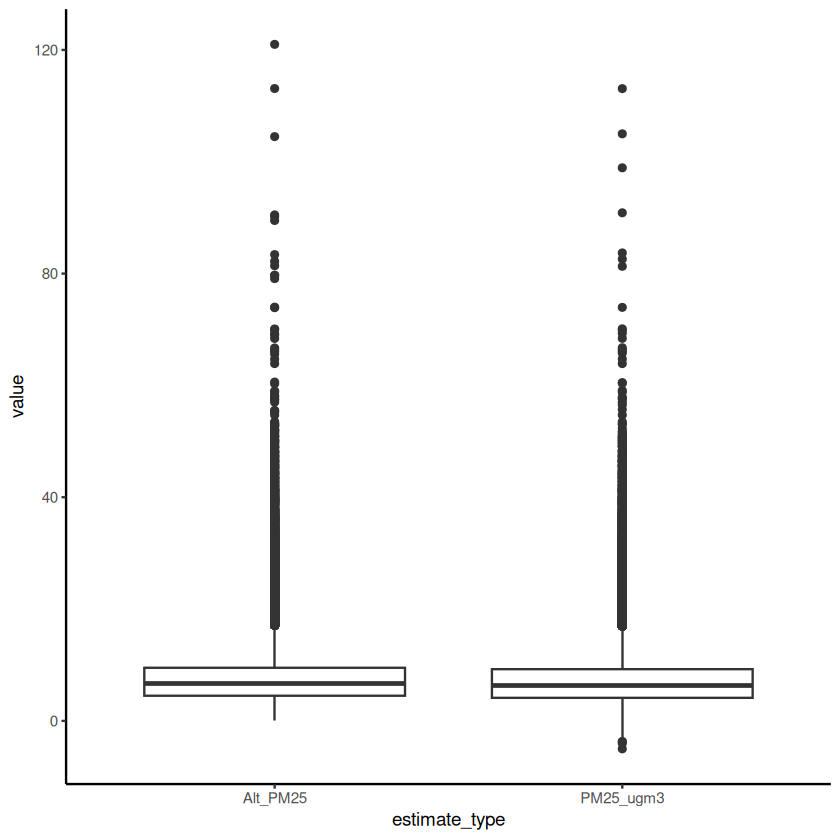

In [6]:
#Purpose of Cell: Assess variabels for possible correlation and identify any outliers
plot(
    x = DF_altpm25_processed$PM25_ugm3, 
    y = DF_altpm25_processed$Alt_PM25, 
    xlab = "Actual PM2.5 Measurements", 
    ylab = "Alternative PM2.5 Estimates", 
    main = "Actual PM2.5 Measurements and Alternative PM2.5 Estimates Scatterplot"
)

#Look for outliers
DF_altpm25_processed %>%
    pivot_longer(c(PM25_ugm3, Alt_PM25), names_to="estimate_type", values_to="value") %>%
    ggplot(aes(x=estimate_type, y=value)) +
    geom_boxplot() +
    theme_classic()

#Conclusion: The variables appear to correlate well with each other, though there are several outliers that may need to be addressed.

Warning message:
“Removed 149877 rows containing non-finite outside the scale range
(`stat_bin()`).”


Warning message:
“Removed 1146 rows containing non-finite outside the scale range (`stat_bin()`).”


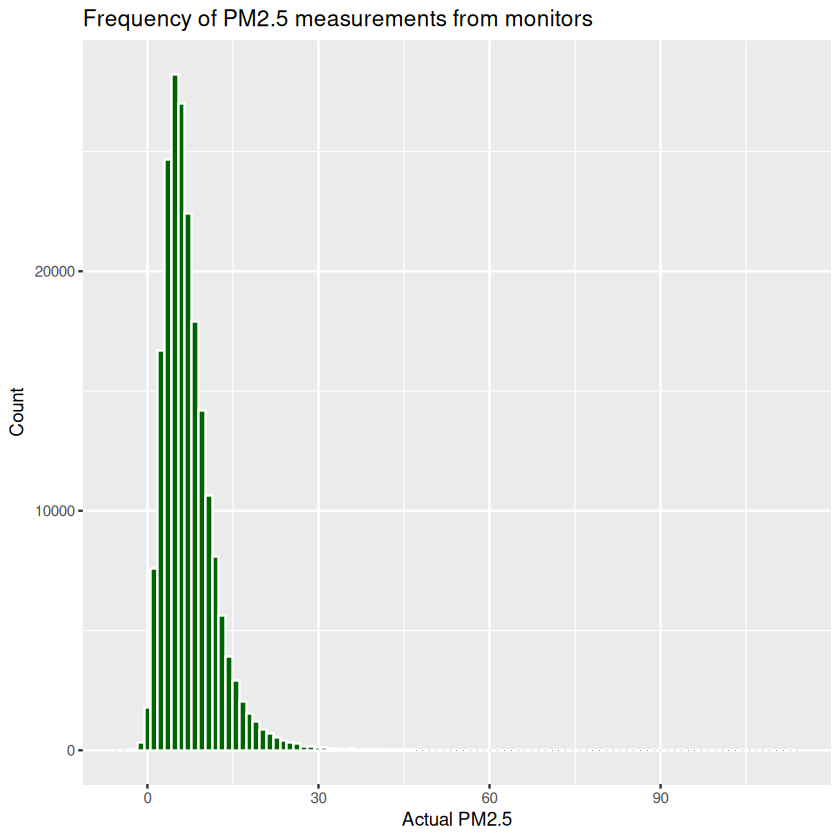

Warning message:
“Removed 151023 rows containing non-finite outside the scale range
(`stat_density()`).”


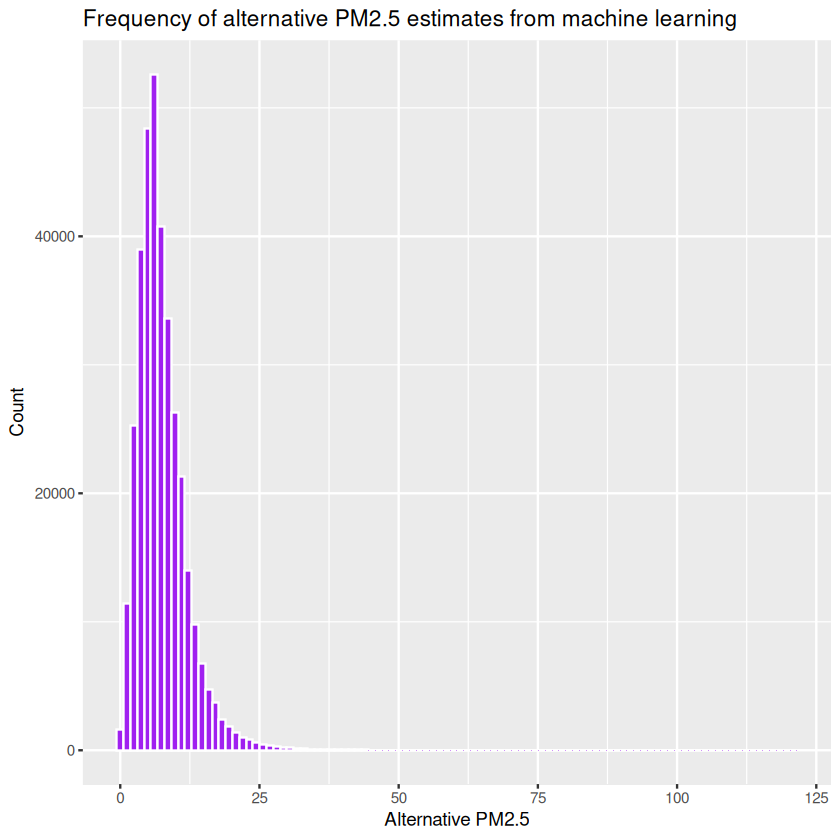

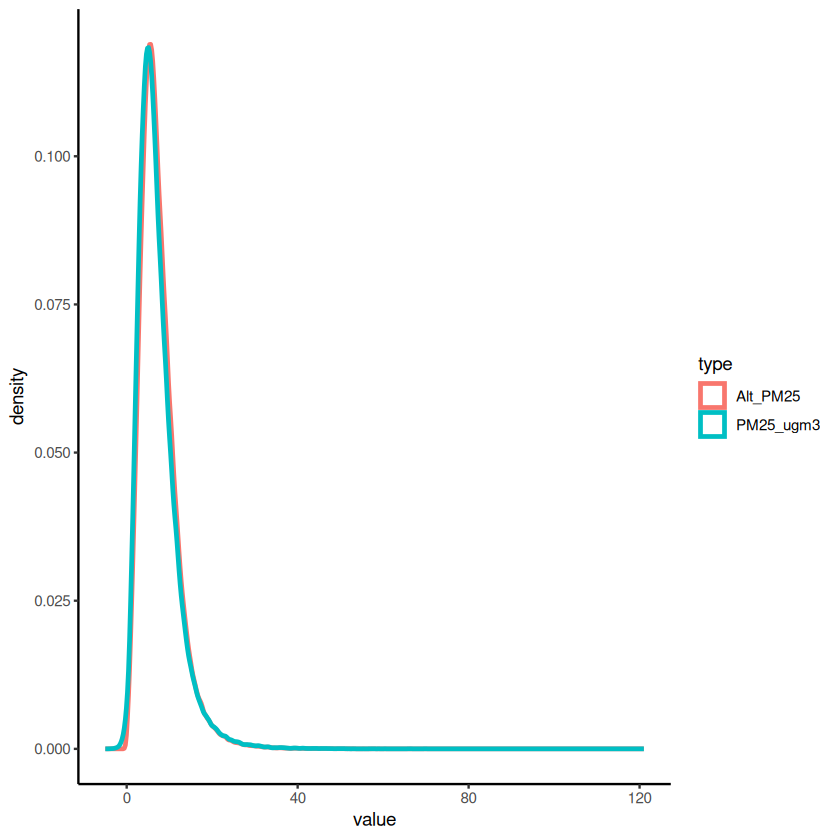

In [7]:
#Purpose of Cell: Check the shape of the data

#Histogram of Actual PM25 using ggplot2.
ggplot(DF_altpm25_processed, aes(x = PM25_ugm3)) +
    geom_histogram(bins= 100, fill = "dark green", color = "white") +
    labs(title = "Frequency of PM2.5 measurements from monitors",
           x = "Actual PM2.5",
           y = "Count")

#Histogram of Alt PM25 using ggplot2.
ggplot(DF_altpm25_processed, aes(x = Alt_PM25)) +
    geom_histogram(bins= 100, fill = "purple", color = "white") +
    labs(title = "Frequency of alternative PM2.5 estimates from machine learning",
           x = "Alternative PM2.5",
           y = "Count")

#Density Plot of Actual PM2.5 and Alt PM2.5
DF_altpm25_processed_long <- DF_altpm25_processed %>%
    pivot_longer(
        cols = c(PM25_ugm3,Alt_PM25),
        names_to = "type",
        values_to = "value",    
    )

ggplot(DF_altpm25_processed_long, aes(x = value, color = type)) +
    geom_density(linewidth = 1) +
    theme_classic()

#Conclusion: Again, the data appears to match well with each other. However, we can clearly see that both are heavily right-skewed. I will have to do additional research to determine whether a natural log transformation is appropriate as a future task but I'm going to go ahead and complete that step now. 

Warning message:
“Removed 149877 rows containing non-finite outside the scale range
(`stat_density()`).”


Warning message in ggally_statistic(data = data, mapping = mapping, na.rm = na.rm, :
“Removed 150710 rows containing missing values”


Warning message:
“Removed 150710 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 1146 rows containing non-finite outside the scale range
(`stat_density()`).”


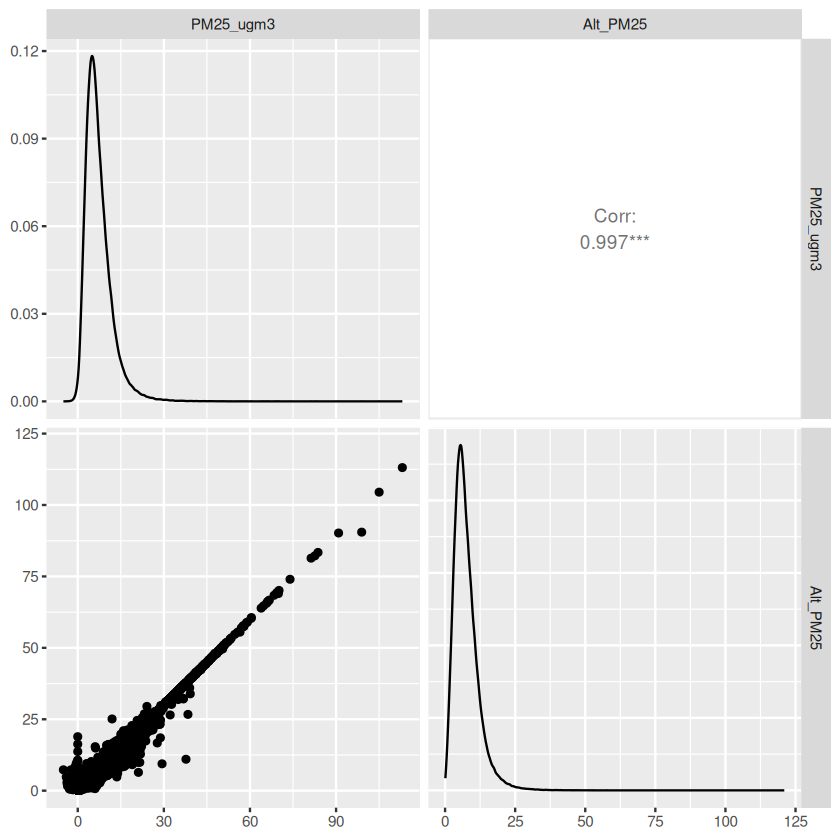

In [8]:
#Purpose of Cell: Check correlation prior to transformation

DF_altpm25_processed01_subset01 <- DF_altpm25_processed %>%
    select(PM25_ugm3, Alt_PM25)

ggpairs(DF_altpm25_processed01_subset01)

#### Compare Data Post-Transformation

In [9]:
#Purpose of Cell: Transform Variables using natural log
DF_altpm25_processed01 <- DF_altpm25_processed %>%
    filter(PM25_ugm3 > 0) %>%
    filter(Alt_PM25> 0) %>%
    mutate(log_PM25_ugm3= log(1 + PM25_ugm3), 
           log_Alt_PM25 = log(1 + Alt_PM25)
          )

head(DF_altpm25_processed01)

#Conclusion: I transformed my variables but I dropped all missing values and values less than 0 (which are impossible but likely due to instrument error). I will need to more closely inspect this data in future research. 

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3,Alt_PM25,log_PM25_ugm3,log_Alt_PM25
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>
1,040031005,31.34920,-109.5397,1445-1449 15TH STREET,Arizona,Cochise,Douglas,2019-01-01,3.833333,3.8,1.575536,1.568616
2,040128000,34.24390,-113.5586,ALAMO LAKE STATE PARK,Arizona,La Paz,Wenden,2019-01-01,4.000000,4.0,1.609438,1.609438
3,040131003,33.41018,-111.8654,"310 S BROOKS, MESA",Arizona,Maricopa,Mesa,2019-01-01,13.983333,14.0,2.706938,2.708050
4,040131004,33.56031,-112.0662,"601 E BUTLER DR ,PHOENIX",Arizona,Maricopa,Phoenix,2019-01-01,16.879167,16.9,2.883636,2.884801
5,040132001,33.57453,-112.1919,"6000 W OLIVE AVE,GLENDALE",Arizona,Maricopa,Glendale,2019-01-01,10.854167,10.9,2.472679,2.476538
6,040134003,33.40314,-112.0753,"33 W TAMARISK AVE, PHOENIX",Arizona,Maricopa,Phoenix,2019-01-01,31.750000,31.6,3.488903,3.484312


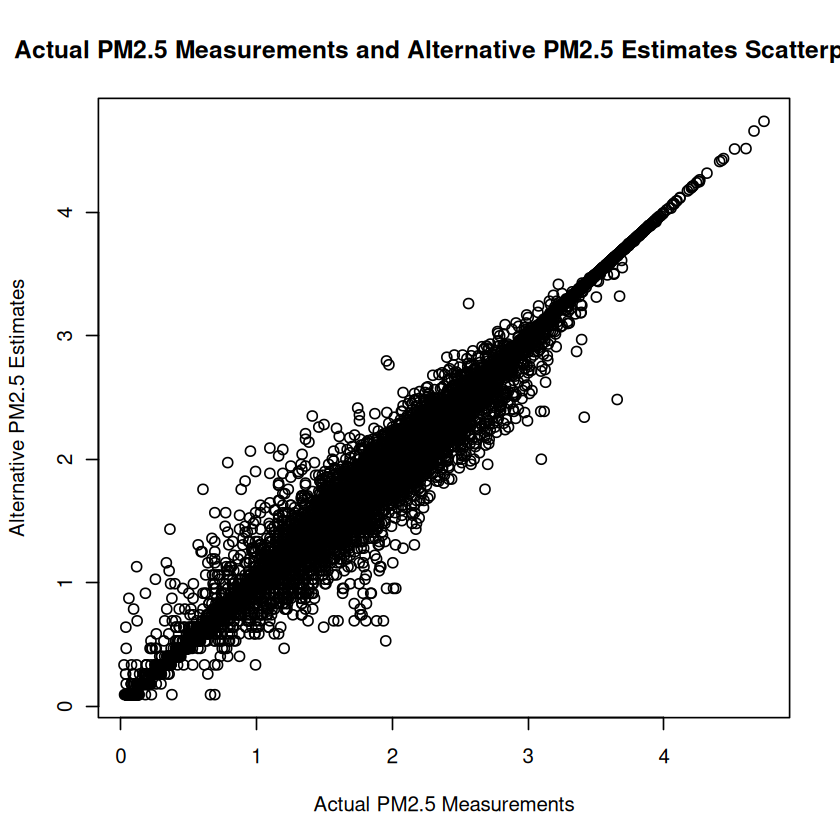

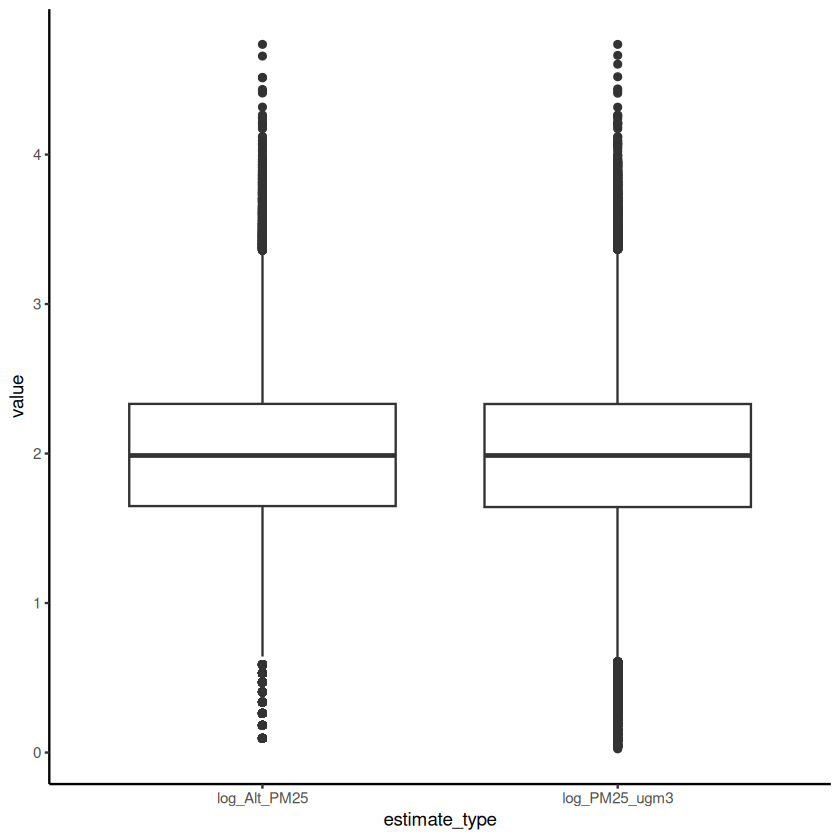

In [10]:
#Purpose of Cell: Assess variabels for possible correlation and identify any outliers
plot(
    x = DF_altpm25_processed01$log_PM25_ugm3, 
    y = DF_altpm25_processed01$log_Alt_PM25, 
    xlab = "Actual PM2.5 Measurements", 
    ylab = "Alternative PM2.5 Estimates", 
    main = "Actual PM2.5 Measurements and Alternative PM2.5 Estimates Scatterplot"
)

#Look for outliers
DF_altpm25_processed01 %>%
    pivot_longer(c(log_PM25_ugm3, log_Alt_PM25), names_to="estimate_type", values_to="value") %>%
    ggplot(aes(x=estimate_type, y=value)) +
    geom_boxplot() +
    theme_classic()

#Conclusion: There are still outliers in the dataset. This wll need to be explored in future research.

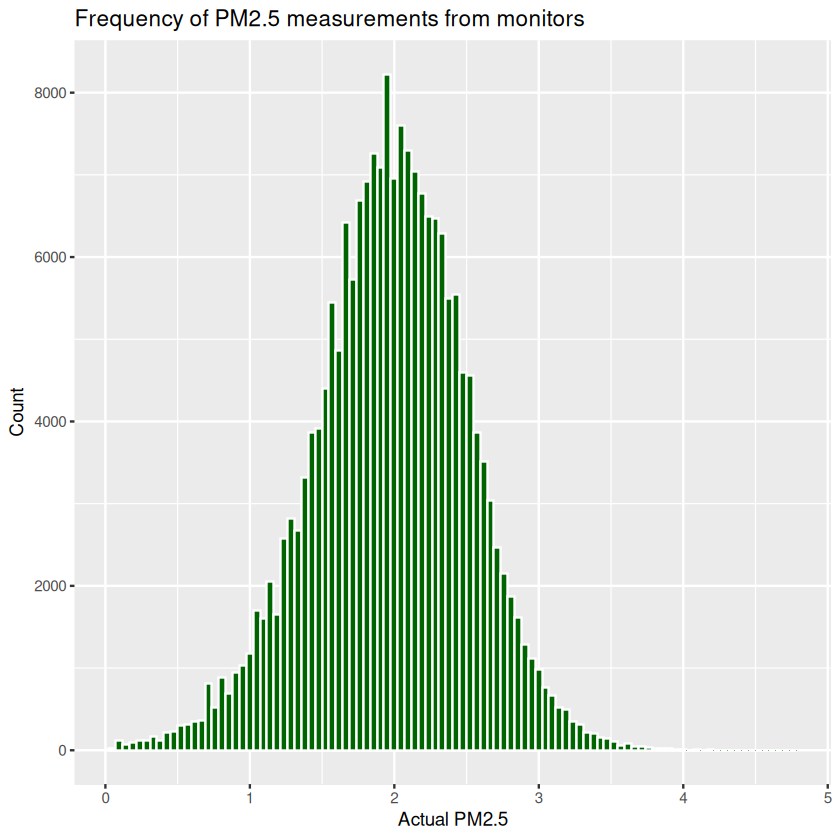

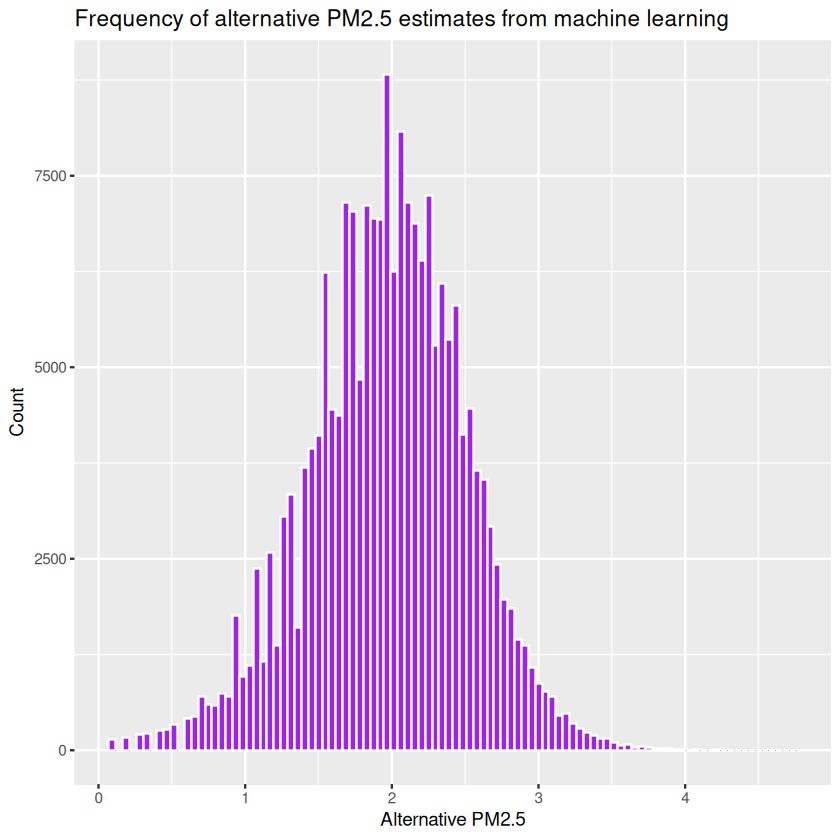

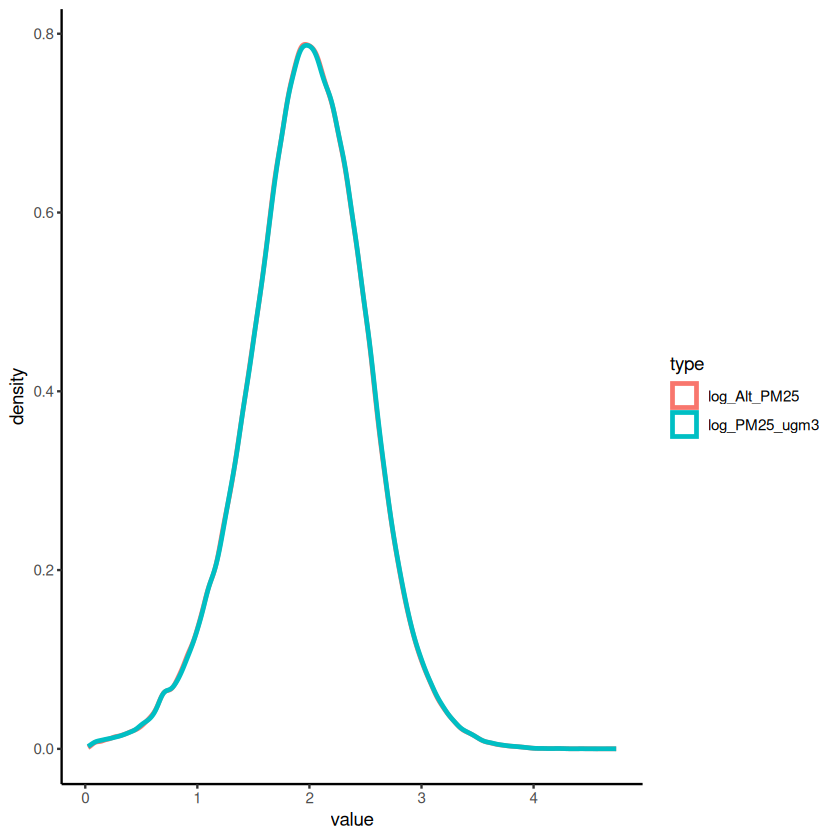

In [11]:
#Purpose of Cell: Check the shape of the data

#Histogram of Actual PM25 using ggplot2.
ggplot(DF_altpm25_processed01, aes(x = log_PM25_ugm3)) +
    geom_histogram(bins= 100, fill = "dark green", color = "white") +
    labs(title = "Frequency of PM2.5 measurements from monitors",
           x = "Actual PM2.5",
           y = "Count")

#Histogram of Alt PM25 using ggplot2.
ggplot(DF_altpm25_processed01, aes(x = log_Alt_PM25)) +
    geom_histogram(bins= 100, fill = "purple", color = "white") +
    labs(title = "Frequency of alternative PM2.5 estimates from machine learning",
           x = "Alternative PM2.5",
           y = "Count")

#Density Plot of Actual PM2.5 and Alt PM2.5
DF_altpm25_processed_long01 <- DF_altpm25_processed01 %>%
    pivot_longer(
        cols = c(log_PM25_ugm3,log_Alt_PM25),
        names_to = "type",
        values_to = "value",    
    )

ggplot(DF_altpm25_processed_long01, aes(x = value, color = type)) +
    geom_density(linewidth = 1) +
    theme_classic()

#Conclusion: The transformation appears to have normally distributed the data. Next step is to test using a QQ plot.

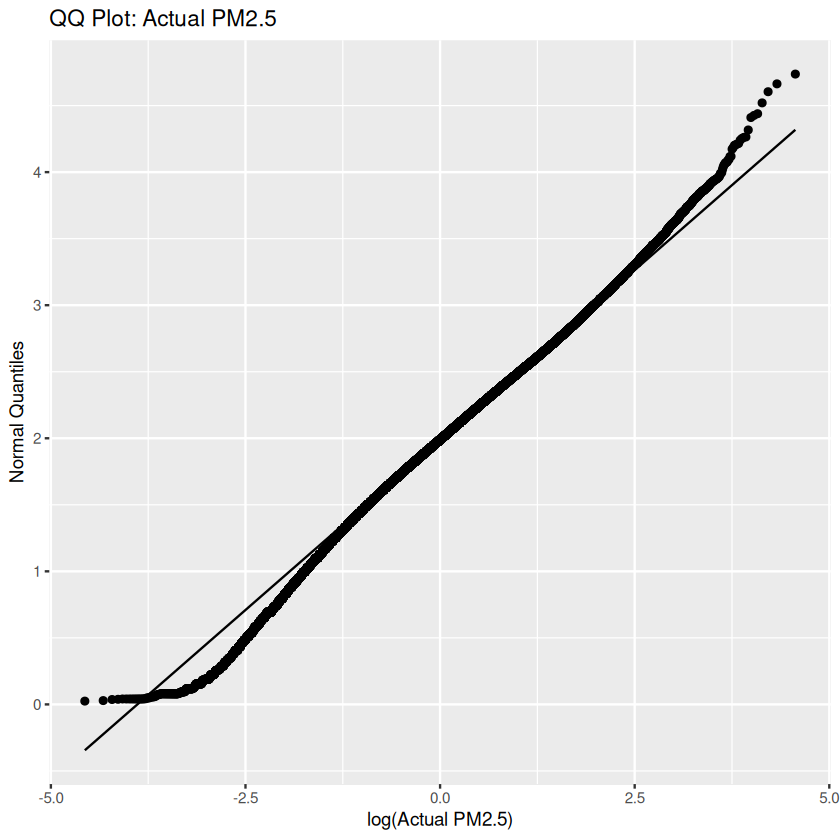

Loading required package: carData




Attaching package: ‘car’




The following object is masked from ‘package:purrr’:

    some




The following object is masked from ‘package:dplyr’:

    recode




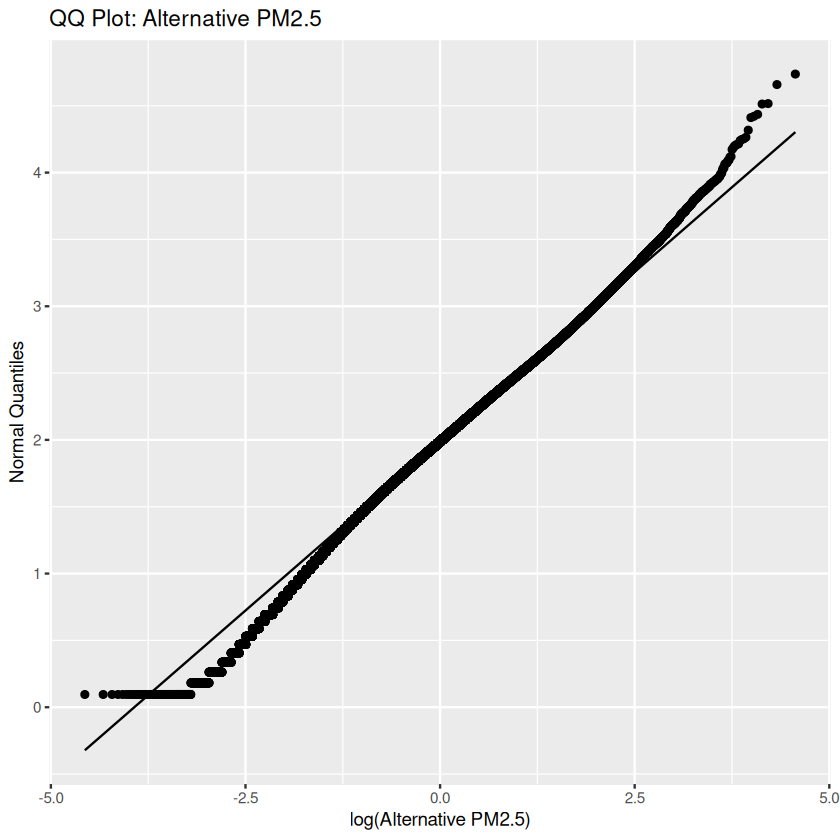

[1] 102915 114076

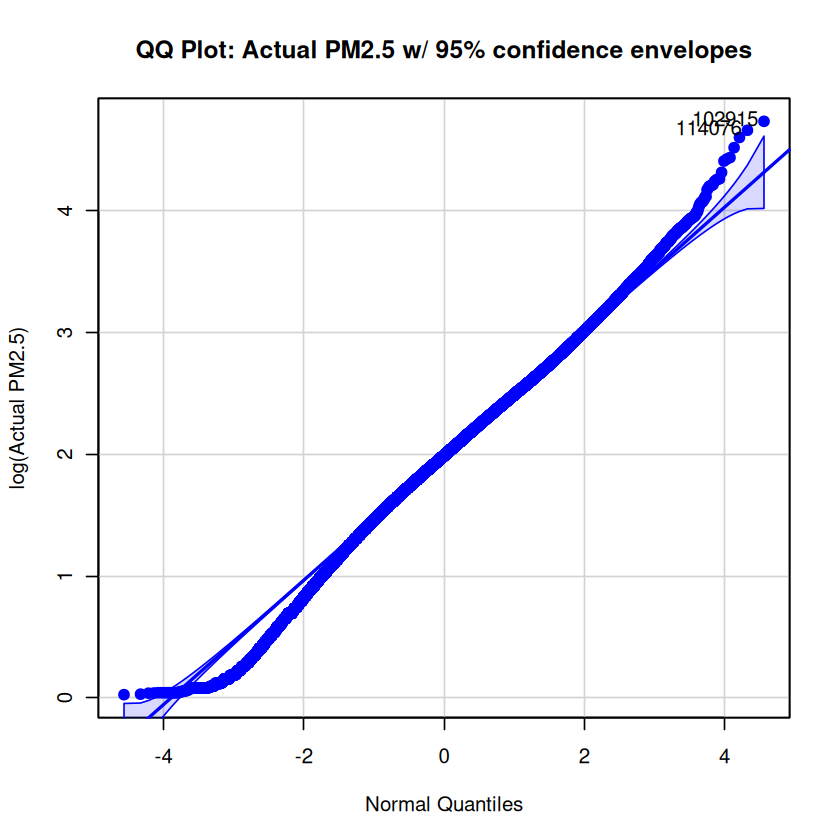

[1] 102915 114076

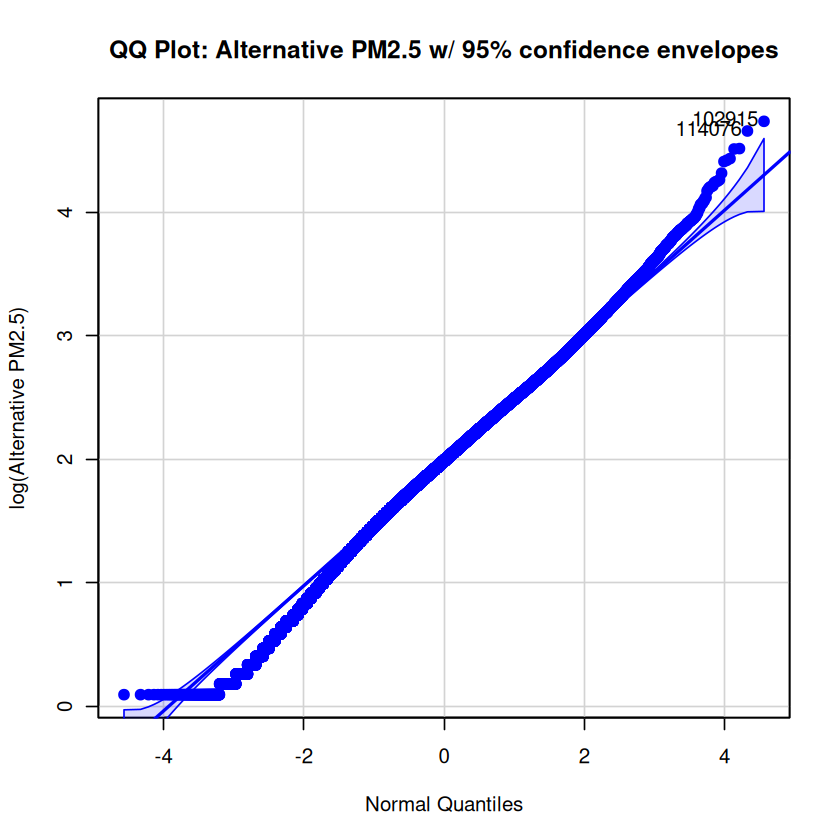

In [12]:
#Purpose of Cell: Check normality of data using QQ plot
ggplot(DF_altpm25_processed01, aes(sample = log_PM25_ugm3)) +
    stat_qq() +
    stat_qq_line() +
    labs(title = "QQ Plot: Actual PM2.5",
           x = "log(Actual PM2.5)",
           y = "Normal Quantiles")

ggplot(DF_altpm25_processed01, aes(sample = log_Alt_PM25)) +
    stat_qq() +
    stat_qq_line() +
    labs(title = "QQ Plot: Alternative PM2.5",
           x = "log(Alternative PM2.5)",
           y = "Normal Quantiles")

library(car)

qqp(DF_altpm25_processed01$log_PM25_ugm3, col = 'blue', main = "QQ Plot: Actual PM2.5 w/ 95% confidence envelopes",  
    ylab = "log(Actual PM2.5)", 
    xlab = "Normal Quantiles",
    pch = 19)

qqp(DF_altpm25_processed01$log_Alt_PM25, col = 'blue', main = "QQ Plot: Alternative PM2.5 w/ 95% confidence envelopes",  
    ylab = "log(Alternative PM2.5)", 
    xlab = "Normal Quantiles",
    pch = 19)

#Conclusion: In each plot, the points tend to deviate from the reference line near the tails, which likely means my transformed variables are nonnormally distributed. I am uncertain whether the violation of the normality assumption would render the correlation analysis invalid given both distributions are very similar. 

              log_PM25_ugm3 log_Alt_PM25
log_PM25_ugm3     1.0000000    0.9976565
log_Alt_PM25      0.9976565    1.0000000


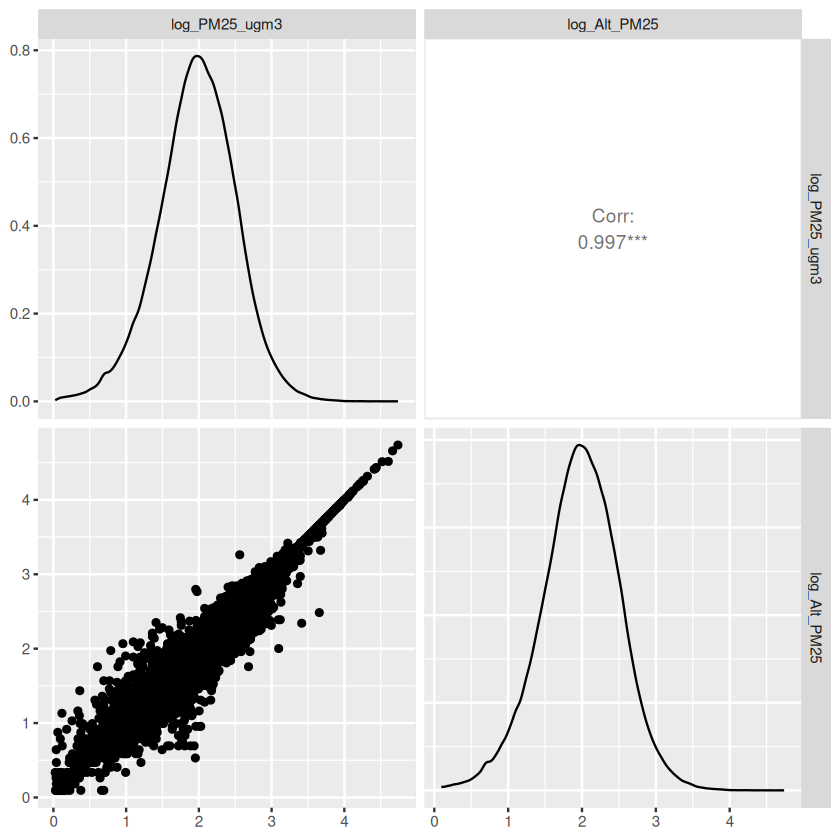

In [13]:
#Purpose of Cell: Conduct a correlation analysis to determine whether the alternative dataset is appropriate to answer my objecitve.

library(GGally)

DF_altpm25_processed01_subset02 <- DF_altpm25_processed01 %>%
    select(log_PM25_ugm3, log_Alt_PM25)

reg_cor <- ggpairs(DF_altpm25_processed01_subset02)
print(reg_cor)

spearman_cor <- cor(DF_altpm25_processed01_subset02, method = "spearman")
print(spearman_cor)
#Conclusion:The transformed alternative PM2.5 dataset has a strong positive relationship with the transformed actual PM2.5 and that correlation is statistically significant. 

#### Publication Diagnostic Plot

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


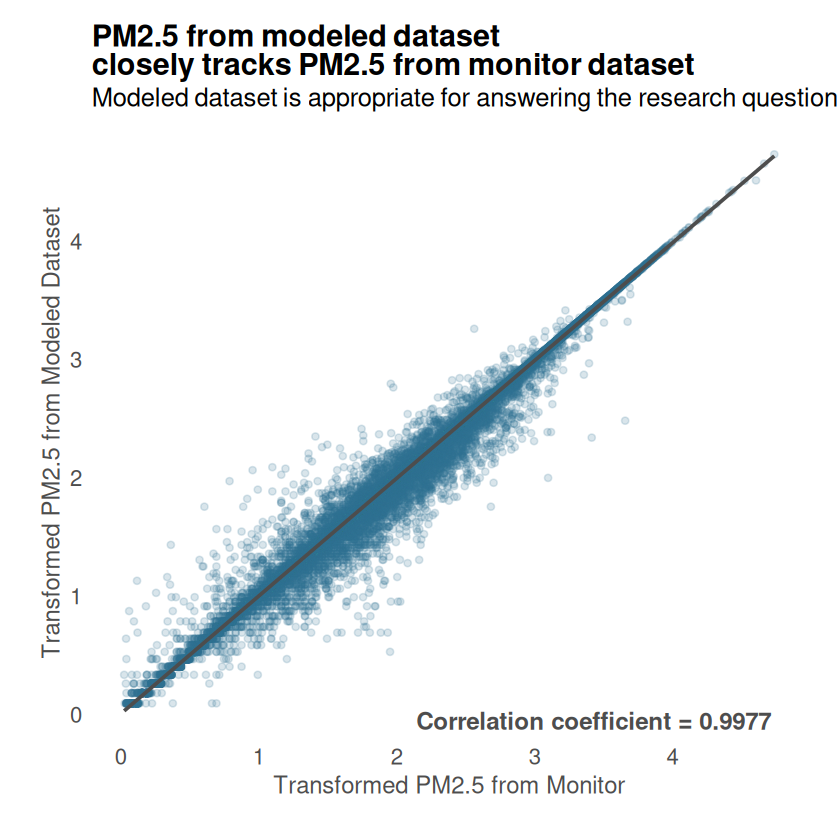

In [20]:
#Purpose of Cell: Assess correlation between observed PM2.5 and alternative dataset

theme_smg <- function() {
  theme_minimal(base_family = "Helvetica", base_size = 13) +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.background = element_blank(),
      plot.background = element_blank(),
      axis.title = element_text(color = "#4D4D4D", size = 14),
      axis.text = element_text(color = "#4D4D4D", size = 13),
      plot.title = ggtext::element_markdown(
        face = "bold",
        size = 18,
        hjust = 0,
        margin = margin(b = 4)
      ),      
      plot.subtitle = ggtext::element_markdown(
        size = 15,
        hjust = 0,
        margin = margin(b = 8)
      ),
      legend.position = "none",
      plot.margin = margin(t = 15, r = 20, b = 25, l = 25)
    )
}

DF_altpm25_processed01_subset02 <- DF_altpm25_processed01 %>%
  select(log_PM25_ugm3, log_Alt_PM25)

# Calculate Spearman correlation
spearman_cor <- cor(
  DF_altpm25_processed01_subset02$log_PM25_ugm3,
  DF_altpm25_processed01_subset02$log_Alt_PM25,
  method = "spearman",
  use = "complete.obs"
)

cor_label <- paste0("Correlation coefficient = ", round(spearman_cor, 4))

diagnostic_cor_plot <- DF_altpm25_processed01_subset02 %>%
  
  ggplot(
    aes(
      x = log_PM25_ugm3,
      y = log_Alt_PM25
    )
  ) +
  
  geom_point(
    color = "#2E6F95",
    alpha = 0.18,
    size = 1.4
  ) +
  
  geom_smooth(
    method = "lm",
    color = "#4D4D4D",
    se = FALSE,
    linewidth = 0.8
  ) +
  
  annotate(
    "text",
    x = Inf,
    y = -Inf,
    label = cor_label,
    hjust = 1.1,
    vjust = -0.5,
    size = 5,
    color = "#4D4D4D",
    fontface = "bold"
  ) +
  
  labs(
    title = "<span style='font-weight:700;'>PM2.5 from modeled dataset <br>closely tracks PM2.5 from monitor dataset</span>",
    subtitle ="Modeled dataset is appropriate for answering the research question",
    x = "Transformed PM2.5 from Monitor",
    y = "Transformed PM2.5 from Modeled Dataset"
  ) +
  
  theme_smg()

diagnostic_cor_plot

ggsave(
  "E_outputs/figures/pm25_correlation_diagnostic.png",
  diagnostic_cor_plot,
  width = 8,
  height = 6,
  dpi = 300
)
